In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,label_binarize

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

wine = load_wine()
X = wine.data
y = wine.target

df = pd.DataFrame(X, columns=wine.feature_names)
df['class'] = y

print("Dataset Shape:", df.shape)
print(df.head())

Dataset Shape: (178, 14)
   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_diluted_wines  prol

Regression

In [2]:
X_reg = df.drop(columns=['alcohol','class'])
y_reg = df['alcohol']

X_train, X_test, y_train, y_test = train_test_split(
    X_reg, y_reg, test_size=0.3, random_state=42)
reg_model = LinearRegression()
reg_model.fit(X_train, y_train)

y_pred_reg = reg_model.predict(X_test)

mea = mean_absolute_error(y_test, y_pred_reg)
mse = mean_squared_error(y_test, y_pred_reg)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_reg)

print("Mean Absolute Error:", mea)
print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)
print("R-squared:", r2)

Mean Absolute Error: 0.38604836056924796
Mean Squared Error: 0.20175903076082488
Root Mean Squared Error: 0.44917594632930297
R-squared: 0.6241637957918121



--- Original Metrics ---
MAE: 0.38604836056924796
MSE: 0.20175903076082488
RMSE: 0.44917594632930297
R2 Score: 0.6241637957918121

--- After Introducing Outliers ---
MAE: 2.6684868963447417
MSE: 57.55999459692768
RMSE: 7.58683033927395
R2 Score: -106.22261007091218


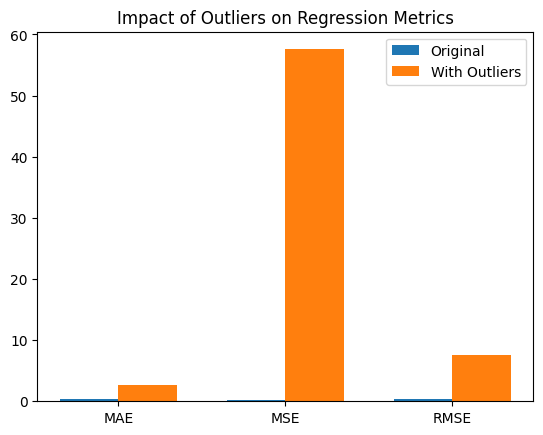

In [3]:
y_pred_original = y_pred_reg.copy()
y_pred_outlier = y_pred_reg.copy()
y_pred_outlier[:5] = y_pred_outlier[:5] + 25

# ----- ORIGINAL METRICS -----
mae_original = mean_absolute_error(y_test, y_pred_original)
mse_original = mean_squared_error(y_test, y_pred_original)
rmse_original = np.sqrt(mse_original)
r2_original = r2_score(y_test, y_pred_original)

# ----- METRICS AFTER ADDING OUTLIERS -----
mae_outlier = mean_absolute_error(y_test, y_pred_outlier)
mse_outlier = mean_squared_error(y_test, y_pred_outlier)
rmse_outlier = np.sqrt(mse_outlier)
r2_outlier = r2_score(y_test, y_pred_outlier)

print("\n--- Original Metrics ---")
print("MAE:", mae_original)
print("MSE:", mse_original)
print("RMSE:", rmse_original)
print("R2 Score:", r2_original)

print("\n--- After Introducing Outliers ---")
print("MAE:", mae_outlier)
print("MSE:", mse_outlier)
print("RMSE:", rmse_outlier)
print("R2 Score:", r2_outlier)

# VISUAL COMPARISON

metrics_names = ["MAE", "MSE", "RMSE"]

original_values = [mae_original, mse_original, rmse_original]
outlier_values = [mae_outlier, mse_outlier, rmse_outlier]

x = np.arange(len(metrics_names))
width = 0.35

plt.figure()
plt.bar(x - width/2, original_values, width, label="Original")
plt.bar(x + width/2, outlier_values, width, label="With Outliers")

plt.xticks(x, metrics_names)
plt.title("Impact of Outliers on Regression Metrics")
plt.legend()
plt.show()

Incase of dataset with outliers mae is preffered evaluation metric as mse and rmse give huge variation and r2 score also is varied.

Classification

Accuracy: 0.9814814814814815
Precision (macro): 0.9777777777777779
Recall (macro): 0.9841269841269842
F1 Score (macro): 0.9803756658256239
Confusion Matrix:
 [[19  0  0]
 [ 0 20  1]
 [ 0  0 14]]
ROC-AUC Score (OvR): 0.9995189995189996


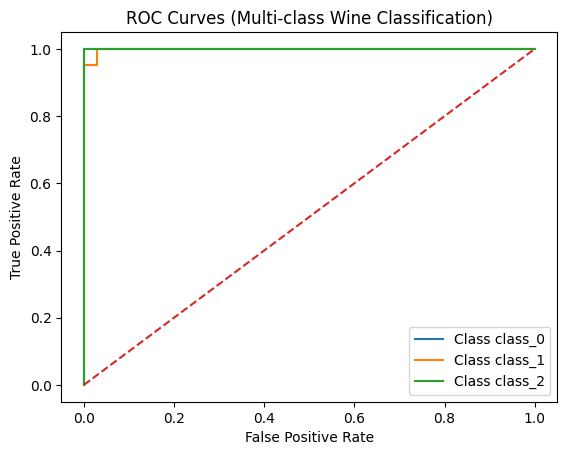

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, roc_curve

X_clf = df.drop(columns=['class'])
y_clf = df['class']

X_train, X_test, y_train, y_test = train_test_split(
    X_clf, y_clf, test_size=0.3, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

clf_model = LogisticRegression(max_iter=5000)
clf_model.fit(X_train, y_train)

y_pred = clf_model.predict(X_test)
y_prob = clf_model.predict_proba(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision (macro):", precision_score(y_test, y_pred, average='macro'))
print("Recall (macro):", recall_score(y_test, y_pred, average='macro'))
print("F1 Score (macro):", f1_score(y_test, y_pred, average='macro'))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
roc_auc = roc_auc_score(y_test_bin, y_prob, multi_class='ovr')
print("ROC-AUC Score (OvR):", roc_auc)

plt.figure()

class_names = wine.target_names

for i in range(len(class_names)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    plt.plot(fpr, tpr, label=f"Class {class_names[i]}")

plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves (Multi-class Wine Classification)")
plt.legend()
plt.show()

For class 0 and 2 model is doing perfect classification, but foe class 1 it is slightly varied. As roc is close to 1 we can say that model is doing best job.

Clustering

In [5]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score, adjusted_rand_score

X_cluster = df.drop(columns=['class'])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

kmeans = KMeans(n_clusters=3, random_state=42)
y_pred_cluster = kmeans.fit_predict(X_scaled)

sil = silhouette_score(X_scaled, y_pred_cluster)
db = davies_bouldin_score(X_scaled, y_pred_cluster)
ch = calinski_harabasz_score(X_scaled, y_pred_cluster)
ari = adjusted_rand_score(y_clf, y_pred_cluster)

print("Silhouette Score:", sil)
print("Davies-Bouldin Score:", db)
print("Calinski-Harabasz Score:", ch)
print("Adjusted Rand Index:", ari)

Silhouette Score: 0.2848589191898987
Davies-Bouldin Score: 1.3891879777181646
Calinski-Harabasz Score: 70.9400080031512
Adjusted Rand Index: 0.8974949815093207


Most appropraite conclusion can be based on ari score as it it based on ground analysis. But based on silhouettes score it is not accurate.